
# Hierarchical PRM — Demo Notebook

Dieses Notebook zeigt die Nutzung der Klasse **`HierarchicalPRM`** (Hauptplaner: Visibility‑PRM, interner PRM: Basic oder Lazy) im Stil der Vorlesungsbeispiele aus dem Repository **intro-path-planning**.

**Voraussetzungen**
- Das Vorlesungs-Repository ist geklont und der Ordner `lectures/` ist im Python‑Pfad (oder liegt im gleichen Ordner wie dieses Notebook).
- Die beiden Dateien aus meiner Implementierung liegen erreichbar im Pfad (gleiche Mappe ist am einfachsten):
  - `hierarchical_prm.py`
  - `visualize_hierarchical_prm.py` (nur für Visualisierung, optional)

> Tipp: Falls du das Repo in einen Unterordner wie `../intro-path-planning` geklont hast, setze unten den Pfad entsprechend.


In [2]:

import sys, os
from pathlib import Path

# Pfad zum geklonten Vorlesungsrepo anpassen, falls nötig (oder leer lassen, wenn 'lectures' bereits importierbar ist)
possible_repo_paths = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent / "intro-path-planning",
    Path.cwd() / "intro-path-planning"
]

for p in possible_repo_paths:
    ldir = p / "lectures"
    if ldir.exists() and ldir.is_dir():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

# Prüfen, ob 'lectures' tatsächlich importierbar ist
try:
    import lectures
    print("lectures package gefunden:", lectures.__file__)
except Exception as e:
    print("Konnte 'lectures' nicht importieren. Bitte sicherstellen, dass das Repo geklont und im Pfad ist.")
    raise e

# Unsere Hierarchical-Implementierung importieren
from hierarchical_prm import HierarchicalPRM
print("HierarchicalPRM geladen.")


lectures package gefunden: None
HierarchicalPRM geladen.


In [3]:

import matplotlib.pyplot as plt
import networkx as nx
from typing import Dict, Any, List

# Aus den Vorlesungen: einfacher CollisionChecker, der Polygone akzeptiert
from lectures.IPEnvironment import CollisionChecker
from shapely.geometry import Polygon

def make_demo_env():
    # Zwei einfache Rechteck-Hindernisse
    scene = {
        'obs1': Polygon([(5, 5), (9, 5), (9, 14), (5, 14)]),
        'obs2': Polygon([(12, 8), (16, 8), (16, 18), (12, 18)]),
    }
    env = CollisionChecker(scene, limits=((0, 22), (0, 22)))
    return env


In [4]:

def plot_graph(ax, graph, alpha_edges=0.8):
    pos = nx.get_node_attributes(graph, 'pos')
    # edges
    for (u, v) in graph.edges():
        if u in pos and v in pos:
            p1, p2 = pos[u], pos[v]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linewidth=0.8, alpha=alpha_edges)
    # nodes
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.scatter(xs, ys, s=15, zorder=3)

def draw_env(ax, env):
    try:
        env.drawObstacles(ax)
    except Exception:
        pass
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, 22); ax.set_ylim(0, 22)

def plot_result(env, planner, path, start, goal, title):
    fig, ax = plt.subplots(figsize=(6,6))
    draw_env(ax, env)
    plot_graph(ax, planner.graph)
    if path:
        pos = nx.get_node_attributes(planner.graph, 'pos')
        xs = [pos[n][0] for n in path]
        ys = [pos[n][1] for n in path]
        ax.plot(xs, ys, linewidth=2.5)
    ax.scatter([start[0]], [start[1]], s=60, marker='*', zorder=5)
    ax.scatter([goal[0]], [goal[1]], s=60, marker='o', zorder=5)
    ax.set_title(title)
    plt.show()



## 1) Einfacher Lauf — interner Planer: BasicPRM


Pfadlänge (Knoten): 13


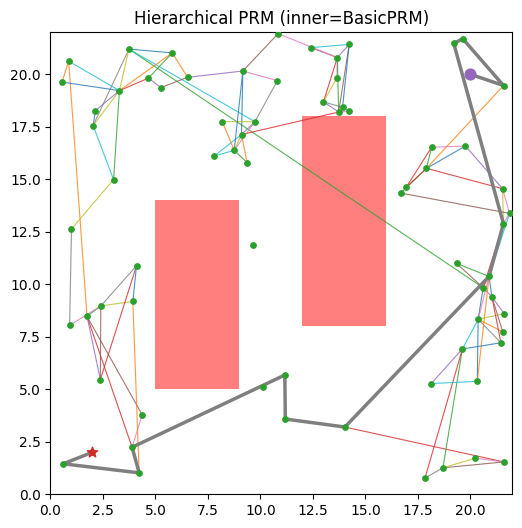

In [7]:

env = make_demo_env()
start = [2.0, 2.0]
goal  = [20.0, 20.0]

planner = HierarchicalPRM(env, inner_type='basic')
config = {
    'ntry': 30,  # Lernbudget für Visibility-PRM
    'inner': {
        'type': 'basic',
        'config': {'radius': 3.0, 'numNodes': 50}  # kleiner lokaler PRM
    }
}

path = planner.planPath([start], [goal], config)
print("Pfadlänge (Knoten):", len(path) if path else 0)
plot_result(env, planner, path, start, goal, "Hierarchical PRM (inner=BasicPRM)")



## 2) Einfacher Lauf — interner Planer: LazyPRM


In [ ]:

env = make_demo_env()
start = [2.0, 2.0]
goal  = [20.0, 20.0]

planner = HierarchicalPRM(env, inner_type='lazy')
config = {
    'ntry': 80,
    'inner': {
        'type': 'lazy',
        'config': {'numNodes': 200, 'kNN': 10, 'maxEdgeLen': 5.0}
    }
}

path = planner.planPath([start], [goal], config)
print("Pfadlänge (Knoten):", len(path) if path else 0)
plot_result(env, planner, path, start, goal, "Hierarchical PRM (inner=LazyPRM)")



## 3) Mini-Benchmark über mehrere Start/Ziel-Paare


In [ ]:

from random import uniform, seed
seed(0)

def random_free_point(env):
    # sehr einfacher Sampler – zieht zufällig aus den Grenzen und verwirft bei Kollision
    (xmin, xmax), (ymin, ymax) = env.limits
    for _ in range(2000):
        p = [uniform(xmin, xmax), uniform(ymin, ymax)]
        if not env.inCollision(p):
            return p
    raise RuntimeError("Kein freier Punkt gefunden. Grenzen/Obstacles prüfen.")

def run_many(env, N=5, inner_type='lazy'):
    planner = HierarchicalPRM(env, inner_type=inner_type)
    cfg = {
        'ntry': 100,
        'inner': {'type': inner_type, 'config': {'numNodes': 180, 'kNN': 10, 'maxEdgeLen': 5.0}}
    }
    found = 0
    lengths = []
    for i in range(N):
        s, g = random_free_point(env), random_free_point(env)
        path = planner.planPath([s], [g], cfg)
        if path:
            found += 1
            lengths.append(len(path))
    return {'queries': N, 'found': found, 'avg_nodes': (sum(lengths)/len(lengths)) if lengths else 0}

env = make_demo_env()
stats = run_many(env, N=5, inner_type='lazy')
stats
